# 05. Análise Exploratória — Sazonalidade de Adições (H4)

## Objetivo deste notebook

Este notebook testa a hipótese de sazonalidade mensal nas adições ao catálogo. A métrica
aqui exige cuidado estatístico: o catálogo cresceu de forma muito desigual ano a ano, então
somar adições por mês em valores absolutos, sem normalizar, faria os meses de anos com mais
volume (ex: 2019, 2020) parecerem "sazonalmente fortes" mesmo sem padrão real algum — um
viés puramente de escala, não de comportamento.

## Hipótese coberta nesta etapa

| ID | Pergunta de Negócio | Métrica Operacional |
|---|---|---|
| **H4** | Existe sazonalidade no abastecimento do catálogo? | Média da participação percentual de cada mês (1–12), calculada **dentro do total de cada ano**, e só então comparada/agregada entre anos |

## Premissa metodológica (decisão já fixada em rodadas anteriores)

- **Não usar contagem absoluta por mês somada entre anos.** Cada mês é primeiro expresso
  como % do total de adições daquele ano específico; a curva de sazonalidade é a média (ou
  distribuição) desses percentuais anuais, não a soma bruta.
- **2021 excluído** por ser ano parcial (mesma regra dos notebooks anteriores).
- Referência temporal: `year_added` / `month_added`, nunca `release_year`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')

NETFLIX_RED = "#E50914"
SILVER = "#B3B3B3"
BG_COLOR = "#141414"
GRID_COLOR = "#2A2A2A"
TEXT_COLOR = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor": BG_COLOR,
    "savefig.facecolor": BG_COLOR,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "axes.titlecolor": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "grid.color": GRID_COLOR,
    "grid.alpha": 0.5,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.figsize": (12, 6),
    "legend.frameon": False,
})
df = pd.read_csv(r'C:\Users\lukin\OneDrive\Documentos\netflix_catalog_analysis\data\processed\netflix_titles_clean.csv')
df['date_added_clean'] = pd.to_datetime(df['date_added_clean'])

df_temp = df.dropna(subset=['date_added_clean']).copy()
df_temp = df_temp[df_temp['year_added'] <= 2020]
month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
               'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
print(f"Registros válidos (até 2020, com date_added): {len(df_temp)}")

Registros válidos (até 2020, com date_added): 7299


In [3]:
yearly_totals = df_temp.groupby('year_added').size().rename('year_total')
print("Volume de títulos por ano:")
print(yearly_totals.sort_index())

MIN_YEARLY_VOLUME = 100
years_valid = yearly_totals[yearly_totals >= MIN_YEARLY_VOLUME].index

years_excluded = sorted(set(yearly_totals.index) - set(years_valid))
print(f"\nAnos excluídos por volume insuficiente (<{MIN_YEARLY_VOLUME} títulos): {years_excluded}")
print(f"Anos mantidos na análise de sazonalidade: {sorted(years_valid)}")

df_temp_seasonality = df_temp[df_temp['year_added'].isin(years_valid)].copy()
print(f"\nRegistros válidos para H4 após filtro de volume: {len(df_temp_seasonality)}")

Volume de títulos por ano:
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
Name: year_total, dtype: int64

Anos excluídos por volume insuficiente (<100 títulos): [2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0]
Anos mantidos na análise de sazonalidade: [2016.0, 2017.0, 2018.0, 2019.0, 2020.0]

Registros válidos para H4 após filtro de volume: 7161


In [4]:
monthly_counts = (
    df_temp_seasonality.groupby(['year_added', 'month_added'])
    .size()
    .rename('count')
    .reset_index()
)

yearly_totals_valid = df_temp_seasonality.groupby('year_added').size().rename('year_total')
monthly_counts = monthly_counts.merge(yearly_totals_valid, on='year_added')

monthly_counts['pct_of_year'] = (monthly_counts['count'] / monthly_counts['year_total']) * 100

seasonality = monthly_counts.groupby('month_added')['pct_of_year'].agg(['mean', 'std', 'count'])
seasonality = seasonality.rename(columns={'count': 'n_anos_observados'})
seasonality.index = month_names

expected_pct = 100 / 12

print("Participação média de cada mês no total anual (%) — anos com volume >= 100 títulos:")
display(seasonality.round(2))
print(f"\nReferência sem sazonalidade: ~{expected_pct:.2f}% por mês.")

Participação média de cada mês no total anual (%) — anos com volume >= 100 títulos:


,mean,std,n_anos_observados
Jan,8.48,1.96,5
Fev,5.82,1.52,5
Mar,8.16,2.72,5
Abr,7.48,1.58,5
Mai,6.28,2.02,5
Jun,6.69,2.05,5
Jul,7.59,1.09,5
Ago,8.18,1.58,5
Set,8.65,1.94,5
Out,10.51,1.28,5



Referência sem sazonalidade: ~8.33% por mês.


In [5]:
top2 = seasonality['mean'].nlargest(2)
top_month = top2.index[0]
diff = top2.iloc[0] - top2.iloc[1]

print(f"Mês líder: {top_month} ({top2.iloc[0]:.2f}%)")
print(f"2º colocado: {top2.index[1]} ({top2.iloc[1]:.2f}%)")
print(f"Diferença entre 1º e 2º: {diff:.2f} pontos percentuais")
print(f"Desvio padrão do mês líder: {seasonality.loc[top_month, 'std']:.2f}")

if diff < seasonality.loc[top_month, 'std']:
    print("\nA diferença entre o 1º e o 2º colocado é menor que o desvio padrão do líder.")
    print("  O destaque de um único mês como 'pico' não é estatisticamente robusto —")
    print("  considerar destacar um grupo de meses em vez de um vencedor isolado.")
else:
    print("\nO mês líder se destaca de forma consistente frente à variação entre anos.")

Mês líder: Dez (12.64%)
2º colocado: Out (10.51%)
Diferença entre 1º e 2º: 2.13 pontos percentuais
Desvio padrão do mês líder: 5.51

A diferença entre o 1º e o 2º colocado é menor que o desvio padrão do líder.
  O destaque de um único mês como 'pico' não é estatisticamente robusto —
  considerar destacar um grupo de meses em vez de um vencedor isolado.


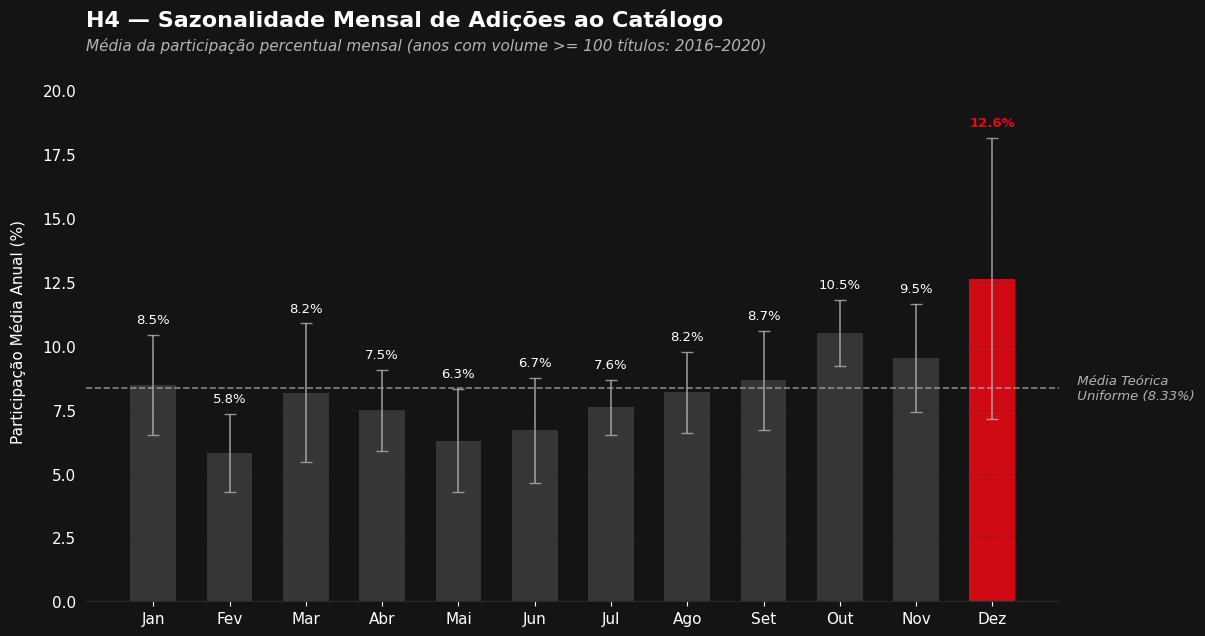

Mês com maior participação média: Dez (12.64% ± 5.51%)
Mês com menor participação média: Fev (5.82% ± 1.52%)


In [6]:
fig, ax = plt.subplots(figsize=(13, 6.5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

max_val = seasonality['mean'].max()
top2 = seasonality['mean'].nlargest(2)
diff = top2.iloc[0] - top2.iloc[1]
std_leader = seasonality.loc[top2.index[0], 'std']

if diff < std_leader:
    bar_colors = [NETFLIX_RED if val >= (max_val - 1.0) else "#3A3A3C" for val in seasonality['mean']]
else:
    bar_colors = [NETFLIX_RED if val == max_val else "#3A3A3C" for val in seasonality['mean']]

bars = ax.bar(
    seasonality.index,
    seasonality['mean'],
    yerr=seasonality['std'],
    capsize=4,
    color=bar_colors,
    alpha=0.9,
    width=0.6,
    error_kw={'ecolor': SILVER, 'elinewidth': 1.2, 'alpha': 0.8}
)

ax.axhline(
    y=expected_pct,
    color=SILVER,
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    zorder=1
)

ax.annotate(
    f" Média Teórica\n Uniforme ({expected_pct:.2f}%)",
    xy=(1, expected_pct),
    xycoords=('axes fraction', 'data'),
    xytext=(10, 0),
    textcoords='offset points',
    color=SILVER,
    fontsize=9.5,
    va='center',
    ha='left',
    style='italic'
)

for bar, mean_val, std_val, m_name in zip(bars, seasonality['mean'], seasonality['std'], seasonality.index):
    is_top = (bar_colors[seasonality.index.get_loc(m_name)] == NETFLIX_RED)
    txt_color = TEXT_COLOR if not is_top else NETFLIX_RED
    weight = 'bold' if is_top else 'normal'
    y_pos = mean_val + std_val + 0.35

    ax.annotate(
        f"{mean_val:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, y_pos),
        ha='center', va='bottom',
        fontsize=9.5, fontweight=weight, color=txt_color
    )

ax.set_title("H4 — Sazonalidade Mensal de Adições ao Catálogo", pad=25, loc='left', fontsize=16)
ax.text(0, 1.02, f"Média da participação percentual mensal (anos com volume >= {MIN_YEARLY_VOLUME} títulos: {min(years_valid):.0f}–2020)",
        transform=ax.transAxes, color=SILVER, fontsize=11, style='italic')

ax.set_ylabel("Participação Média Anual (%)", labelpad=12)
ax.set_ylim(0, seasonality['mean'].max() + seasonality['std'].max() + 3.0)

ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(GRID_COLOR)
ax.tick_params(left=False, labelleft=True)
ax.yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(right=0.82) 
plt.show()

low_month = seasonality['mean'].idxmin()
print(f"Mês com maior participação média: {top_month} ({seasonality.loc[top_month, 'mean']:.2f}% ± {seasonality.loc[top_month, 'std']:.2f}%)")
print(f"Mês com menor participação média: {low_month} ({seasonality.loc[low_month, 'mean']:.2f}% ± {seasonality.loc[low_month, 'std']:.2f}%)")

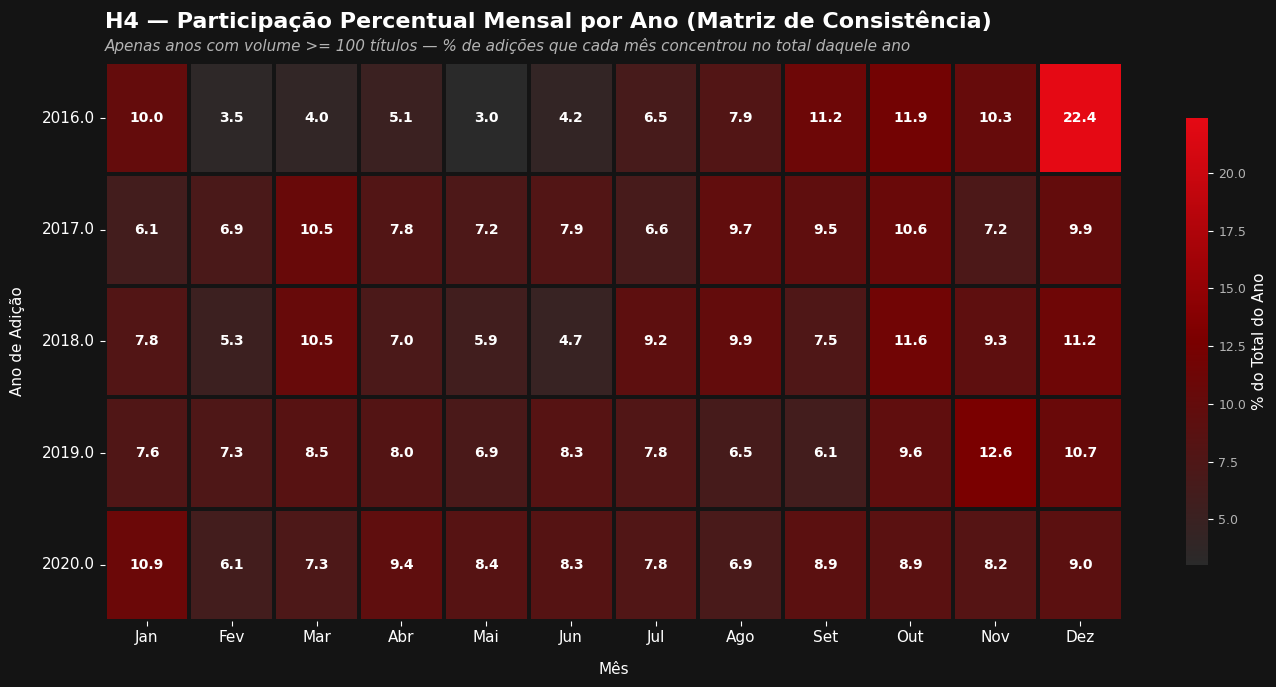

In [7]:
from matplotlib.colors import LinearSegmentedColormap
pivot = monthly_counts.pivot(index='year_added', columns='month_added', values='pct_of_year')
pivot.columns = month_names

netflix_cmap = LinearSegmentedColormap.from_list(
    "netflix_heatmap",
    [GRID_COLOR, "#7A0000", NETFLIX_RED]
)

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

heatmap = sns.heatmap(
    pivot,
    cmap=netflix_cmap,
    annot=True,
    fmt='.1f',
    linewidths=1.5,
    linecolor=BG_COLOR,
    cbar_kws={'label': '% do Total do Ano', 'shrink': 0.8},
    ax=ax,
    annot_kws={"size": 10, "weight": "bold", "color": TEXT_COLOR}
)

cbar = heatmap.collections[0].colorbar
cbar.ax.yaxis.label.set_color(TEXT_COLOR)
cbar.ax.tick_params(labelsize=9, labelcolor=SILVER)
cbar.outline.set_edgecolor(GRID_COLOR)

ax.set_title("H4 — Participação Percentual Mensal por Ano (Matriz de Consistência)", pad=25, loc='left', fontsize=16)
ax.text(0, 1.02, f"Apenas anos com volume >= {MIN_YEARLY_VOLUME} títulos — % de adições que cada mês concentrou no total daquele ano",
        transform=ax.transAxes, color=SILVER, fontsize=11, style='italic')

ax.set_xlabel("Mês", labelpad=12, fontsize=11)
ax.set_ylabel("Ano de Adição", labelpad=12, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()